# Earth motion module

In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import numpy as np
import matplotlib.pyplot as plt

from snudd.geometry import SolarAngles

We will load the geometry module to compute nadir angles over a data taking period. 

NOTE: The geometry module outputs the cos(nadir)

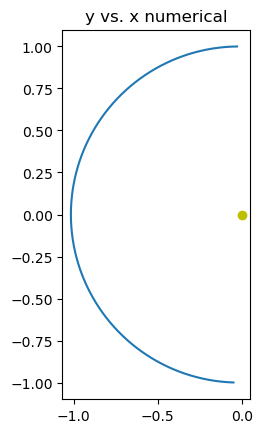

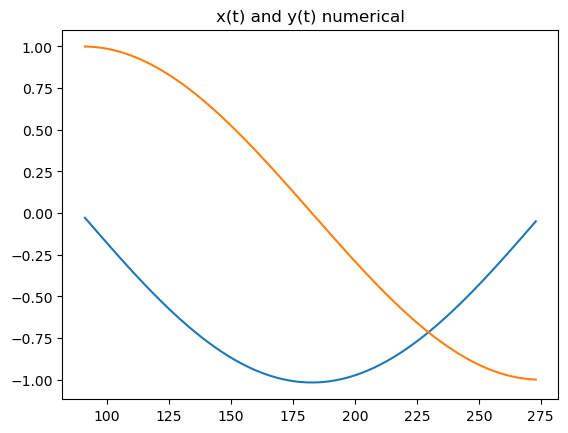

In [ ]:
# Data taking period: 
# t0 - beginning in days after 3rd January (perihelion)
# T  - duration of data taking beginngin at t0 in days
t0 = 91
T  = 182


latitude_surf = 44.35 # Latitude of SURF (LZ)
latitude_gs   = 42.47 # Latitude of Gran Sasso
latitude_panda = 28.15 # Latitude of Jinping
GranSasso = SolarAngles(latitude=latitude_gs, t0=t0, T=T)


# Calculate orbital positions
times, coords = GranSasso.orbit()
x, y = coords.T[:2]
dist = np.sqrt(np.pow(x,2) + np.pow(y,2))     # Earth-Sun distance r in AU



# Plot orbit and angles
if True:
    f = plt.figure()
    # f.set_figheight(15)
    plt.subplot(1, 1, 1)
    plt.plot(x, y)
    plt.plot([0], [0], 'oy')
    plt.gca().set_aspect('equal')
    plt.title('y vs. x numerical')
    plt.show()

    plt.subplot(1, 1, 1)
    plt.plot(times, x)
    plt.plot(times, y)
    # plt.xlim(-pi, pi)
    plt.title('x(t) and y(t) numerical')

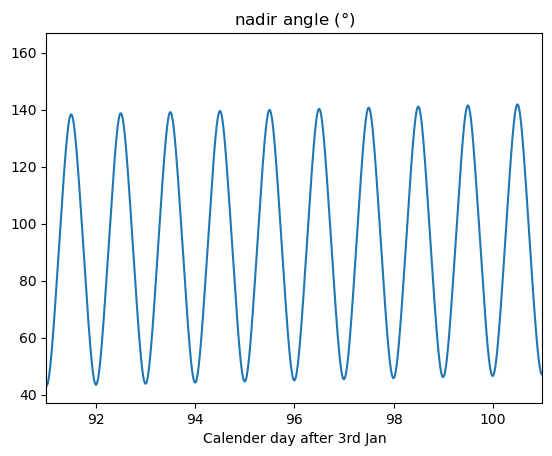

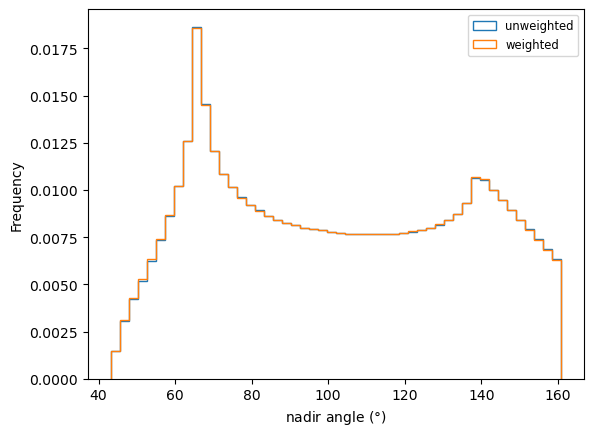

[ 0.71584543  0.68652054  0.6560338   0.62443682  0.59178306  0.55812779
  0.52352796  0.48804213  0.45173036  0.41465409  0.37687608  0.33846025
  0.29947162  0.25997618  0.22004077  0.17973296  0.13912098  0.09827356
  0.05725982  0.01614918 -0.02498879 -0.06608448 -0.10706832 -0.14787096
 -0.18842336 -0.22865687 -0.26850341 -0.30789554 -0.3467666  -0.38505081
 -0.42268337 -0.4596006  -0.49574001 -0.53104045 -0.56544217 -0.59888696
 -0.63131821 -0.66268104 -0.69292238 -0.72199103 -0.74983782 -0.7764156
 -0.8016794  -0.82558647 -0.84809634 -0.86917093 -0.88877456 -0.90687405
 -0.92343879 -0.93844073] [0.00344662 0.00718266 0.00983929 0.01212815 0.01459046 0.01712644
 0.02002439 0.02360424 0.02909186 0.04282365 0.03343746 0.02780147
 0.02499432 0.02336996 0.02212222 0.02119422 0.020544   0.01990538
 0.01942974 0.01903945 0.01882126 0.01845191 0.01827159 0.01812327
 0.01791113 0.01782682 0.01771535 0.01767981 0.01764344 0.01765947
 0.01769078 0.01771471 0.01786938 0.01799455 0.01819858 

In [ ]:
# Calculate nadir cnadirs in data taking period
times, nads = GranSasso.nadir_cnadirs()
nads *= 180 / np.pi    # convert angles to degrees



# Plot nadir angle as a function of time
f = plt.figure()
# f.set_figheight(15)
plt.plot(times, nads)
plt.xlabel("Calender day after 3rd Jan")
plt.title(r'nadir angle ($\degree$)')
plt.xlim(t0,t0+10)
# plt.subplots_adjust(wspace=None, hspace=0.5)
plt.show()


# bin the nadir angles
ax = plt.hist(nads, density=True, bins=50, histtype='step', ls='--', label='unweighted')  # density=False would make counts
plt.hist(nads, weights=1/np.pow(dist,2), density=True, bins=50, histtype='step', label='weighted')  # density=False would make counts
plt.ylabel('Frequency')
plt.xlabel(r'nadir angle ($\degree$)')
plt.legend(fontsize='small')
# plt.text(min(nads)*0.9, 0.55, r'lat = %s$^\degree$'%latitude, ha='center', va='top')
plt.show()


cnadirs, weights = GranSasso.nadir_hist(bins=50)
print(cnadirs, weights)
print("Sum of weights (data taking flux/average flux):", sum(weights))

## Night time only histogram

In [39]:
cnadirs, weights = GranSasso.nadir_hist(bins=50)
cnadirs > 0

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [ ]:
# np.putmask(weights, cnadirs < 0, 0)  
# print(weights)

cnadirs_night = cnadirs[cnadirs > 0]
weights_night = weights[cnadirs > 0]

weights_night /= sum(weights_night)  # Normalize weights to sum to 1
nadirs_night = np.arccos(cnadirs_night) * 180 / np.pi  # Convert cnadirs to nadir angles in degrees

print("Night nadirs (degrees):", nadirs_night)
print("Sum of night weights:", weights_night.sum())

Night nadirs (degrees): [44.28747199 46.64469347 49.00191494 51.35913641 53.71635788 56.07357936
 58.43080083 60.7880223  63.14524377 65.50246525 67.85968672 70.21690819
 72.57412966 74.93135114 77.28857261 79.64579408 82.00301555 84.36023703
 86.7174585  89.07467997]
Sum of night weights: 1.0


<BarContainer object of 20 artists>

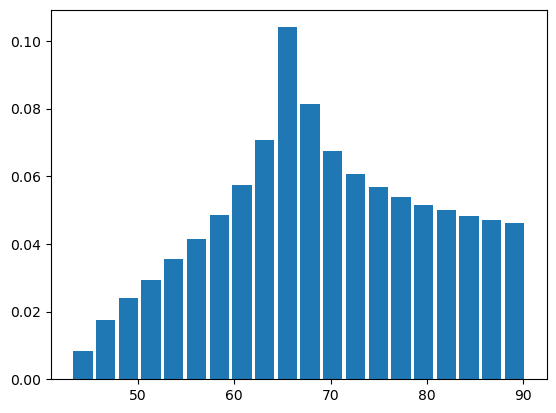

In [43]:
plt.bar(nadirs_night, weights_night, width=2)